# Distribution Shift Plots for Lo-Hi Hi Datasets

This notebook generates the paper-style figures for the pairwise fold distribution-shift analysis.

It does not fit models and does not recompute feature importances. All computational artifacts are loaded from the previous notebook:

`01_distribution_shift_tables.ipynb`

The analysis is restricted to the valid Hi datasets used in the OOD-holdout vs random-shuffle protocol comparison:

- DRD2-Hi
- HIV-Hi
- Sol-Hi

KDR-Hi is excluded from this plotting notebook because KDR-Hi is not part of the valid OOD-holdout vs random-shuffle protocol comparison.

Loaded artifacts:

- `cross_dataset_discrimination_same_search_cv.csv`
- `cross_dataset_discrimination_high_capacity_insample.csv`
- `cross_dataset_listA_activity_feature_importance.csv`
- `cross_dataset_listB_same_search_cv_feature_importance.csv`
- `cross_dataset_listA_listB_overlap_by_protocol_foldaware_multi_k.csv`
- `cross_dataset_pairwise_shift_vs_protocol_gap.csv`
- `predictive_shift_overlap_granular_top20.csv`
- `predictive_shift_overlap_pair_summary_top20.csv`

The figures answer three questions:

1. Are the Lo-Hi folds distinguishable from molecular features?
2. Do shift features overlap with activity-model features?
3. Does stronger predictive shift correspond to greater OOD-validation benefit?

The shift score is:

\[
s = \max(0, 2 \cdot \mathrm{balanced\ accuracy} - 1)
\]

where \(s = 0\) means that the fold discriminator is no better than chance, and \(s = 1\) means perfect fold distinguishability.


In [1]:
from __future__ import annotations

import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.colors import TwoSlopeNorm

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=".*X does not have valid feature names.*",
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Plot notebook initialized.")

Plot notebook initialized.


In [2]:
def find_project_root(start: Path | None = None) -> Path:
    """
    Walk upward until the project root is found.
    """
    if start is None:
        start = Path.cwd().resolve()

    current = start
    while current != current.parent:
        if (
            (current / "data").exists()
            and (current / "utils").exists()
            and (current / "results").exists()
        ):
            return current
        current = current.parent

    raise RuntimeError(
        "Could not find project root containing data/, utils/, and results/."
    )


PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

TASK = "hi"

DATASETS_MAIN = ["drd2", "hiv", "sol"]
DATASETS = DATASETS_MAIN

DATASET_LABELS = {
    "drd2": "DRD2",
    "hiv": "HIV",
    "sol": "Sol",
    "kdr": "KDR",
}

OUT_ROOT = PROJECT_ROOT / "results" / "results_classifier_shift_test" / TASK
FIG_ROOT = OUT_ROOT / "figures"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

OOD_CROSS_DIR = (
    PROJECT_ROOT / "results" / "results_ood_vs_random_shuffle" / TASK / "cross_dataset"
)

PLOT_FPS = ["ecfp4", "maccs"]
PLOT_MODELS = ["DT", "LR", "SVM"]

TOP_K_VALUES_OVERLAP = [10, 20, 50, 100, 150, 200]
OVERLAP_K = 50

FP_N_FEATURES = {
    "ecfp4": 2048,
    "maccs": 167,
}

PAIR_TO_OUTER_FOLD = {
    "F1_vs_F2": 1,
    "F1_vs_F3": 2,
    "F2_vs_F3": 3,
}

OUTER_FOLD_TO_PAIR = {
    1: "F1_vs_F2",
    2: "F1_vs_F3",
    3: "F2_vs_F3",
}

PAIR_LABELS = {
    "F1_vs_F2": "F1–F2",
    "F1_vs_F3": "F1–F3",
    "F2_vs_F3": "F2–F3",
}

PAIR_MARKERS = {
    "F1_vs_F2": "o",
    "F1_vs_F3": "s",
    "F2_vs_F3": "^",
}

DATASET_COLORS = {
    "drd2": "#4C78A8",
    "hiv": "#F58518",
    "sol": "#B279A2",
}

print(f"Project root : {PROJECT_ROOT}")
print(f"Output root  : {OUT_ROOT}")
print(f"Figure root  : {FIG_ROOT}")

Project root : /home/f.capria/drug-discovery-lohi
Output root  : /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi
Figure root  : /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi/figures


In [3]:
def read_required_csv(path: Path, name: str) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file for {name}: {path}")
    df = pd.read_csv(path)
    print(f"{name:<35} {df.shape}  <- {path.name}")
    return df


def keep_main_datasets(df: pd.DataFrame, name: str) -> pd.DataFrame:
    if len(df) == 0 or "dataset" not in df.columns:
        return df

    before = len(df)
    df = df[df["dataset"].isin(DATASETS_MAIN)].copy()
    after = len(df)

    if before != after:
        print(f"{name}: dropped {before - after} rows from excluded datasets")

    assert "kdr" not in set(df["dataset"]), f"KDR found in {name}"
    return df


search_cv_path = OUT_ROOT / "cross_dataset_discrimination_same_search_cv.csv"
insample_path = OUT_ROOT / "cross_dataset_discrimination_high_capacity_insample.csv"
listA_path = OUT_ROOT / "cross_dataset_listA_activity_feature_importance.csv"
listB_path = OUT_ROOT / "cross_dataset_listB_same_search_cv_feature_importance.csv"
overlap_path = (
    OUT_ROOT / "cross_dataset_listA_listB_overlap_by_protocol_foldaware_multi_k.csv"
)
shift_gap_path = OUT_ROOT / "cross_dataset_pairwise_shift_vs_protocol_gap.csv"
predictive_granular_path = OUT_ROOT / "predictive_shift_overlap_granular_top20.csv"
predictive_pair_path = OUT_ROOT / "predictive_shift_overlap_pair_summary_top20.csv"

df_search_cv = read_required_csv(search_cv_path, "df_search_cv")
df_insample = read_required_csv(insample_path, "df_insample")
df_listA = read_required_csv(listA_path, "df_listA")
df_listB = read_required_csv(listB_path, "df_listB")
df_overlap = read_required_csv(overlap_path, "df_overlap")
df_shift_gap = read_required_csv(shift_gap_path, "df_shift_gap")
predictive_shift_granular = read_required_csv(
    predictive_granular_path,
    "predictive_shift_granular",
)
plot_df = read_required_csv(predictive_pair_path, "predictive_shift_pair_summary")

df_search_cv = keep_main_datasets(df_search_cv, "df_search_cv")
df_insample = keep_main_datasets(df_insample, "df_insample")
df_listA = keep_main_datasets(df_listA, "df_listA")
df_listB = keep_main_datasets(df_listB, "df_listB")
df_overlap = keep_main_datasets(df_overlap, "df_overlap")
df_shift_gap = keep_main_datasets(df_shift_gap, "df_shift_gap")
predictive_shift_granular = keep_main_datasets(
    predictive_shift_granular,
    "predictive_shift_granular",
)
plot_df = keep_main_datasets(plot_df, "predictive_shift_pair_summary")

print("\nLoaded all plotting inputs.")

df_search_cv                        (63, 28)  <- cross_dataset_discrimination_same_search_cv.csv
df_insample                         (81, 16)  <- cross_dataset_discrimination_high_capacity_insample.csv


/tmp/ipykernel_3624085/3662352290.py:4: DtypeWarning: Columns (0: used_in_tree, 1: permutation_scoring, 2: permutation_eval_set) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


df_listA                            (123516, 32)  <- cross_dataset_listA_activity_feature_importance.csv
df_listB                            (61758, 27)  <- cross_dataset_listB_same_search_cv_feature_importance.csv
df_overlap                          (648, 18)  <- cross_dataset_listA_listB_overlap_by_protocol_foldaware_multi_k.csv
df_shift_gap                        (9, 18)  <- cross_dataset_pairwise_shift_vs_protocol_gap.csv
predictive_shift_granular           (54, 22)  <- predictive_shift_overlap_granular_top20.csv
predictive_shift_pair_summary       (9, 15)  <- predictive_shift_overlap_pair_summary_top20.csv

Loaded all plotting inputs.


In [4]:
required_shift_cols = [
    "cv_balanced_accuracy_mean",
    "cv_roc_auc_mean",
    "shift_score_01",
    "proxy_A_distance",
]

missing = [c for c in required_shift_cols if c not in df_search_cv.columns]
if missing:
    raise ValueError(f"Missing required columns in df_search_cv: {missing}")

nan_counts = df_search_cv[required_shift_cols].isna().sum()
bad_nan_counts = nan_counts[nan_counts > 0]

if len(bad_nan_counts) > 0:
    raise ValueError(
        "NaN values detected in main shift table:\n" + bad_nan_counts.to_string()
    )

assert "high_capacity_insample" not in set(
    df_search_cv.get("evaluation", pd.Series(dtype=str))
), "df_search_cv should contain only out-of-sample shift estimates."

if "source" in df_listB.columns:
    sources = sorted(df_listB["source"].dropna().unique().tolist())
    print(f"List B sources loaded: {sources}")

    assert sources == ["same_search_cv"], (
        "Plot notebook should use only same_search_cv List B. "
        f"Found sources: {sources}"
    )

required_overlap_cols = [
    "dataset",
    "pair",
    "fingerprint",
    "model",
    "activity_protocol",
    "k",
    "overlap",
    "overlap_enrichment",
]

missing_overlap = [c for c in required_overlap_cols if c not in df_overlap.columns]
if missing_overlap:
    raise ValueError(f"Missing required columns in df_overlap: {missing_overlap}")

present_k = sorted(df_overlap["k"].dropna().astype(int).unique().tolist())
missing_k = [k for k in TOP_K_VALUES_OVERLAP if k not in present_k]

if missing_k:
    raise ValueError(f"Missing overlap rows for k values: {missing_k}")

required_gap_cols = [
    "dataset",
    "pair",
    "shift_score_01",
    "optimism_gap_diff",
    "test_gap",
]

missing_gap = [c for c in required_gap_cols if c not in df_shift_gap.columns]
if missing_gap:
    raise ValueError(f"Missing required columns in df_shift_gap: {missing_gap}")

print("OK: all required plotting tables and columns are available.")

List B sources loaded: ['same_search_cv']
OK: all required plotting tables and columns are available.


In [5]:
mpl.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 9,
        "axes.titlesize": 11,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 9,
        "legend.fontsize": 8,
        "legend.title_fontsize": 8.5,
        "figure.dpi": 150,
        "savefig.dpi": 600,
        "axes.linewidth": 0.8,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    }
)

print("Plot style configured.")

Plot style configured.


## Global fold-shift heatmap and Per-Model Fold-Shift Heatmaps

C’è distribution shift tra i fold?


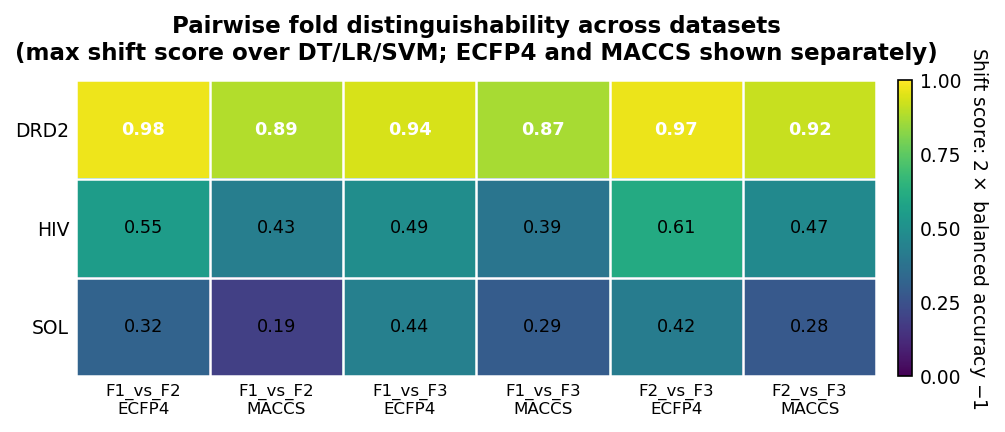

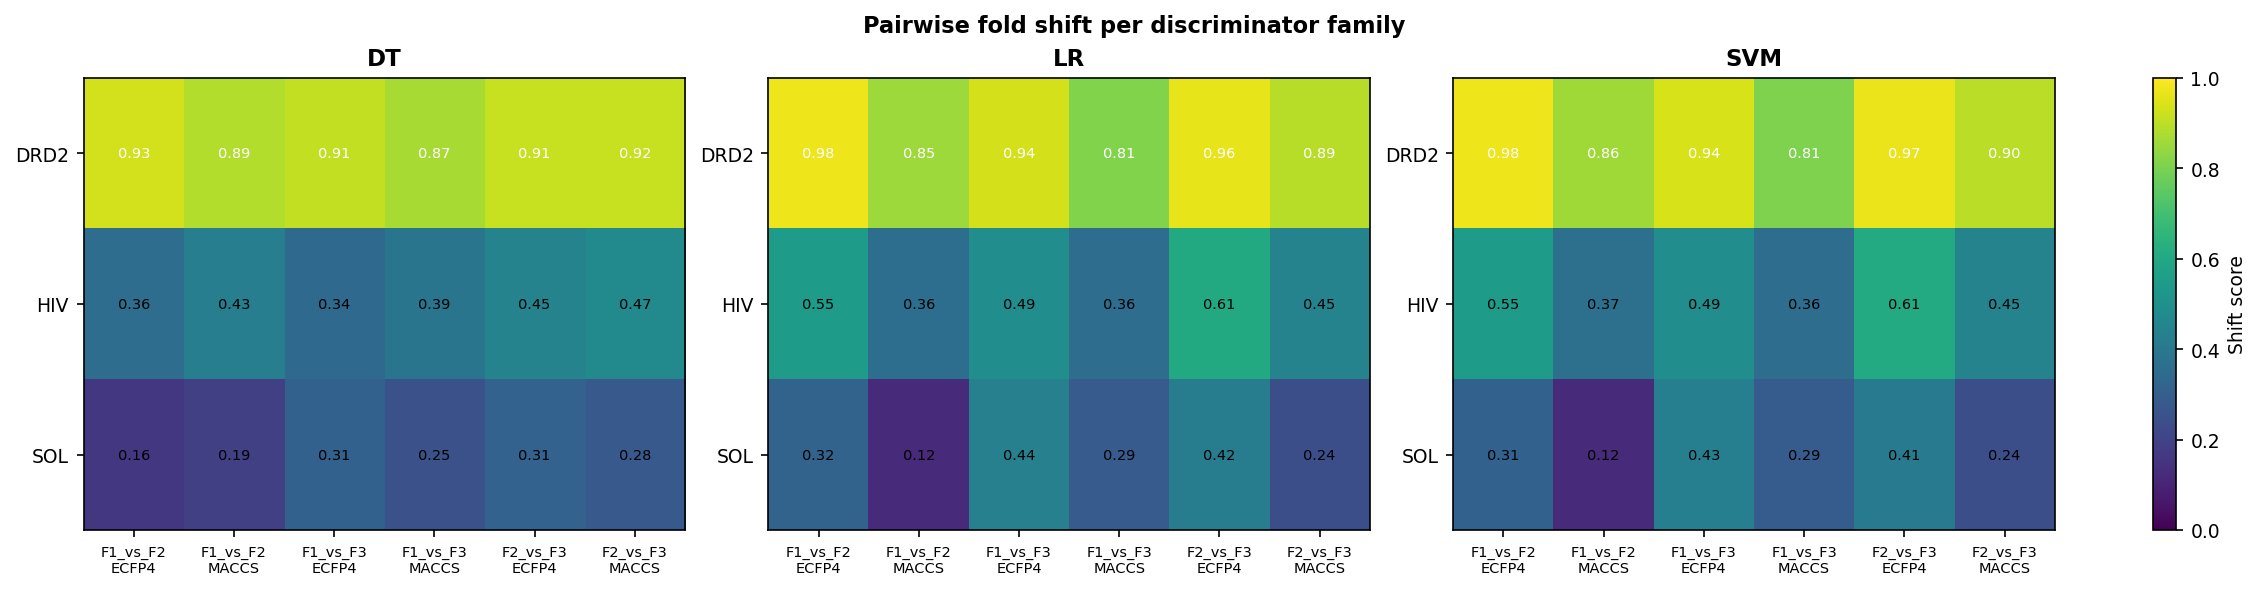

In [6]:
from textwrap import wrap
import matplotlib as mpl

# Global figure directory
FIG_ROOT = OUT_ROOT / "figures"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

PLOT_FPS = ["ecfp4", "maccs"]

df_shift_plot = (
    df_search_cv.query("fingerprint in @PLOT_FPS")
    .groupby(["dataset", "pair", "fingerprint"], as_index=False)
    .agg(
        shift_score_mean=("shift_score_01", "mean"),
        shift_score_max=("shift_score_01", "max"),
    )
)

SHIFT_AGG_COL = "shift_score_max"

df_shift_plot["column"] = (
    df_shift_plot["pair"] + "\n" + df_shift_plot["fingerprint"].str.upper()
)

shift_mat = df_shift_plot.pivot(
    index="dataset", columns="column", values=SHIFT_AGG_COL
).reindex(DATASETS)

ordered_cols = []
for pair in ["F1_vs_F2", "F1_vs_F3", "F2_vs_F3"]:
    for fp in ["ECFP4", "MACCS"]:
        col = f"{pair}\n{fp}"
        if col in shift_mat.columns:
            ordered_cols.append(col)

shift_mat = shift_mat[ordered_cols]

mpl.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 9,
        "axes.titlesize": 11,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 9,
        "figure.dpi": 150,
        "savefig.dpi": 600,
        "axes.linewidth": 0.8,
    }
)

n_rows, n_cols = shift_mat.shape

fig_width = max(6.8, 1.0 * n_cols)
fig_height = max(2.6, 0.55 * n_rows + 1.3)

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# Mask missing values, if any
data = np.ma.masked_invalid(shift_mat.values.astype(float))

cmap = mpl.colormaps["viridis"].copy()
cmap.set_bad(color="lightgray")

im = ax.imshow(
    data,
    vmin=0,
    vmax=1,
    cmap=cmap,
    aspect="auto",
    interpolation="nearest",
)

ax.set_title(
    "Pairwise fold distinguishability across datasets\n"
    "(max shift score over DT/LR/SVM; ECFP4 and MACCS shown separately)",
    pad=10,
    fontweight="bold",
)

ax.set_xticks(np.arange(n_cols))
ax.set_xticklabels(shift_mat.columns, rotation=0, ha="center")

ax.set_yticks(np.arange(n_rows))
ax.set_yticklabels([d.upper() for d in shift_mat.index])

ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)

ax.grid(which="minor", color="white", linewidth=1.2)
ax.tick_params(which="minor", bottom=False, left=False)
ax.tick_params(axis="both", length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

for i in range(n_rows):
    for j in range(n_cols):
        value = shift_mat.iloc[i, j]

        if pd.notna(value):
            text_color = "white" if value >= 0.62 else "black"

            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8.5,
                color=text_color,
                fontweight="bold" if value >= 0.80 else "normal",
            )

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.035,
    pad=0.025,
)

cbar.set_label(
    r"Shift score: $2 \times$ balanced accuracy $- 1$",
    rotation=270,
    labelpad=14,
)

cbar.set_ticks([0, 0.25, 0.50, 0.75, 1.00])
cbar.ax.tick_params(length=0)

fig.tight_layout()

fig.savefig(
    FIG_ROOT / "global_fold_shift_heatmap_shift_score_01.png",
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    FIG_ROOT / "global_fold_shift_heatmap_shift_score_01.pdf",
    bbox_inches="tight",
)

plt.show()

# Per-model shift heatmaps (one panel per discriminator family)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), constrained_layout=True)

for ax, model_name in zip(axes, ["DT", "LR", "SVM"]):
    sub = (
        df_search_cv.query("fingerprint in @PLOT_FPS and model == @model_name")
        .groupby(["dataset", "pair", "fingerprint"], as_index=False)["shift_score_01"]
        .mean()
    )
    sub["column"] = sub["pair"] + "\n" + sub["fingerprint"].str.upper()
    mat = sub.pivot(index="dataset", columns="column", values="shift_score_01").reindex(
        DATASETS
    )
    mat = mat[[c for c in ordered_cols if c in mat.columns]]

    im = ax.imshow(
        np.ma.masked_invalid(mat.values.astype(float)),
        vmin=0,
        vmax=1,
        cmap=cmap,
        aspect="auto",
        interpolation="nearest",
    )
    ax.set_title(model_name, fontweight="bold")
    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels(mat.columns, rotation=0, fontsize=7)
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels([d.upper() for d in mat.index])
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.iloc[i, j]
            if pd.notna(v):
                ax.text(
                    j,
                    i,
                    f"{v:.2f}",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color="white" if v >= 0.62 else "black",
                )

fig.colorbar(im, ax=axes, fraction=0.02, label="Shift score")
fig.suptitle("Pairwise fold shift per discriminator family", fontweight="bold", y=1.05)
fig.savefig(FIG_ROOT / "shift_heatmap_per_model.png", dpi=600, bbox_inches="tight")
plt.show()

## Feature-Overlap Heatmaps by Validation Protocol


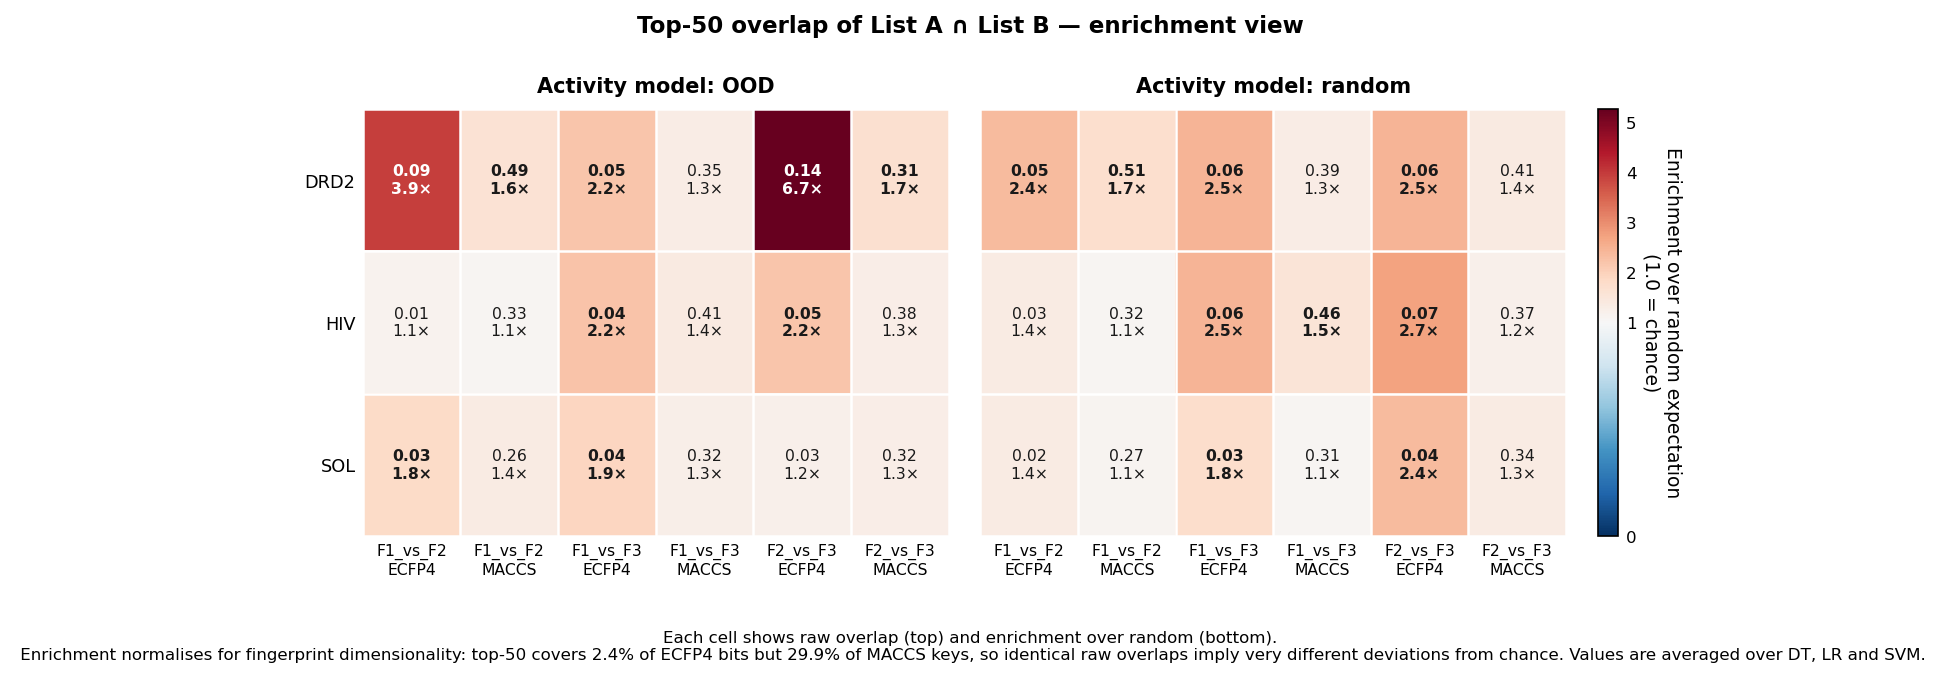

In [7]:
from matplotlib.colors import TwoSlopeNorm

FIG_ROOT = OUT_ROOT / "figures"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 8.5,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 7.5,
        "ytick.labelsize": 8.5,
        "figure.dpi": 150,
        "savefig.dpi": 600,
        "axes.linewidth": 0.8,
    }
)

ordered_cols = []
for pair in ["F1_vs_F2", "F1_vs_F3", "F2_vs_F3"]:
    for fp in ["ECFP4", "MACCS"]:
        ordered_cols.append(f"{pair}\n{fp}")

protocol_labels = {
    "ood": "Activity model: OOD",
    "random": "Activity model: random",
}

df_overlap_plot_k = df_overlap[df_overlap["k"].astype(int) == int(OVERLAP_K)].copy()

# Robust upper bound for the diverging color scale.
finite_enr = (
    df_overlap_plot_k["overlap_enrichment"].replace([np.inf, -np.inf], np.nan).dropna()
)
if len(finite_enr) == 0:
    raise ValueError("No finite enrichment values available.")

vcenter = 1.0
vmin = 0.0
vmax = float(max(2.0, np.nanpercentile(finite_enr, 95)))

norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

cmap = mpl.colormaps["RdBu_r"].copy()
cmap.set_bad(color="lightgray")

fig = plt.figure(figsize=(10.8, 3.7))
gs = fig.add_gridspec(
    nrows=1,
    ncols=3,
    width_ratios=[1, 1, 0.035],
    wspace=0.08,
)
axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]
cax = fig.add_subplot(gs[0, 2])

last_im = None

for ax, protocol in zip(axes, ["ood", "random"]):
    sub = (
        df_overlap_plot_k.query("activity_protocol == @protocol")
        .groupby(["dataset", "pair", "fingerprint"], as_index=False)
        .agg(
            overlap=("overlap", "mean"),
            overlap_enrichment=("overlap_enrichment", "mean"),
        )
    )

    sub["column"] = sub["pair"] + "\n" + sub["fingerprint"].str.upper()

    mat_enr = sub.pivot(
        index="dataset", columns="column", values="overlap_enrichment"
    ).reindex(DATASETS_MAIN)
    mat_raw = sub.pivot(index="dataset", columns="column", values="overlap").reindex(
        DATASETS_MAIN
    )

    mat_enr = mat_enr[[c for c in ordered_cols if c in mat_enr.columns]]
    mat_raw = mat_raw[[c for c in ordered_cols if c in mat_raw.columns]]

    data = np.ma.masked_invalid(mat_enr.values.astype(float))

    last_im = ax.imshow(
        data,
        cmap=cmap,
        norm=norm,
        aspect="auto",
        interpolation="nearest",
    )

    ax.set_title(protocol_labels[protocol], fontweight="bold", pad=8)

    ax.set_xticks(np.arange(mat_enr.shape[1]))
    ax.set_xticklabels(mat_enr.columns, rotation=0, ha="center")
    ax.set_yticks(np.arange(mat_enr.shape[0]))
    ax.set_yticklabels([d.upper() for d in mat_enr.index])

    ax.set_xticks(np.arange(-0.5, mat_enr.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, mat_enr.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.2)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.tick_params(axis="both", length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

    # Cell annotation: raw overlap on top, enrichment below. Color of the
    # text switches to white only when the underlying enrichment is in
    # the upper portion of the scale (dark red).
    text_threshold = vcenter + 0.65 * (vmax - vcenter)

    for i in range(mat_enr.shape[0]):
        for j in range(mat_enr.shape[1]):
            enr = mat_enr.iloc[i, j]
            raw = mat_raw.iloc[i, j]

            if pd.notna(enr) and pd.notna(raw):
                color = "white" if enr >= text_threshold else "0.10"
                weight = "bold" if enr >= 1.5 else "normal"
                ax.text(
                    j,
                    i,
                    f"{raw:.2f}\n{enr:.1f}×",
                    ha="center",
                    va="center",
                    fontsize=7.5,
                    color=color,
                    fontweight=weight,
                )

axes[1].tick_params(labelleft=False)

cbar = fig.colorbar(last_im, cax=cax)
cbar.set_label(
    "Enrichment over random expectation\n(1.0 = chance)",
    rotation=270,
    labelpad=22,
)
cbar.ax.tick_params(length=0, labelsize=8)

fig.suptitle(
    f"Top-{OVERLAP_K} overlap of List A ∩ List B — enrichment view",
    fontweight="bold",
    y=1.05,
    fontsize=11,
)

fig.text(
    0.5,
    -0.06,
    "Each cell shows raw overlap (top) and enrichment over random (bottom).\n "
    "Enrichment normalises for fingerprint dimensionality: top-"
    f"{OVERLAP_K} covers {OVERLAP_K / 2048:.1%} of ECFP4 bits but "
    f"{OVERLAP_K / 167:.1%} of MACCS keys, so identical raw overlaps imply "
    "very different deviations from chance. "
    "Values are averaged over DT, LR and SVM.",
    ha="center",
    va="top",
    fontsize=8,
)

fig.savefig(
    FIG_ROOT / f"listA_listB_overlap_enrichment_by_protocol_top{OVERLAP_K}.png",
    dpi=600,
    bbox_inches="tight",
)
fig.savefig(
    FIG_ROOT / f"listA_listB_overlap_enrichment_by_protocol_top{OVERLAP_K}.pdf",
    bbox_inches="tight",
)

plt.show()

Saved: listA_listB_raw_overlap_foldwise_ood_linear_ecfp4.png
Saved: listA_listB_raw_overlap_foldwise_ood_linear_ecfp4.pdf


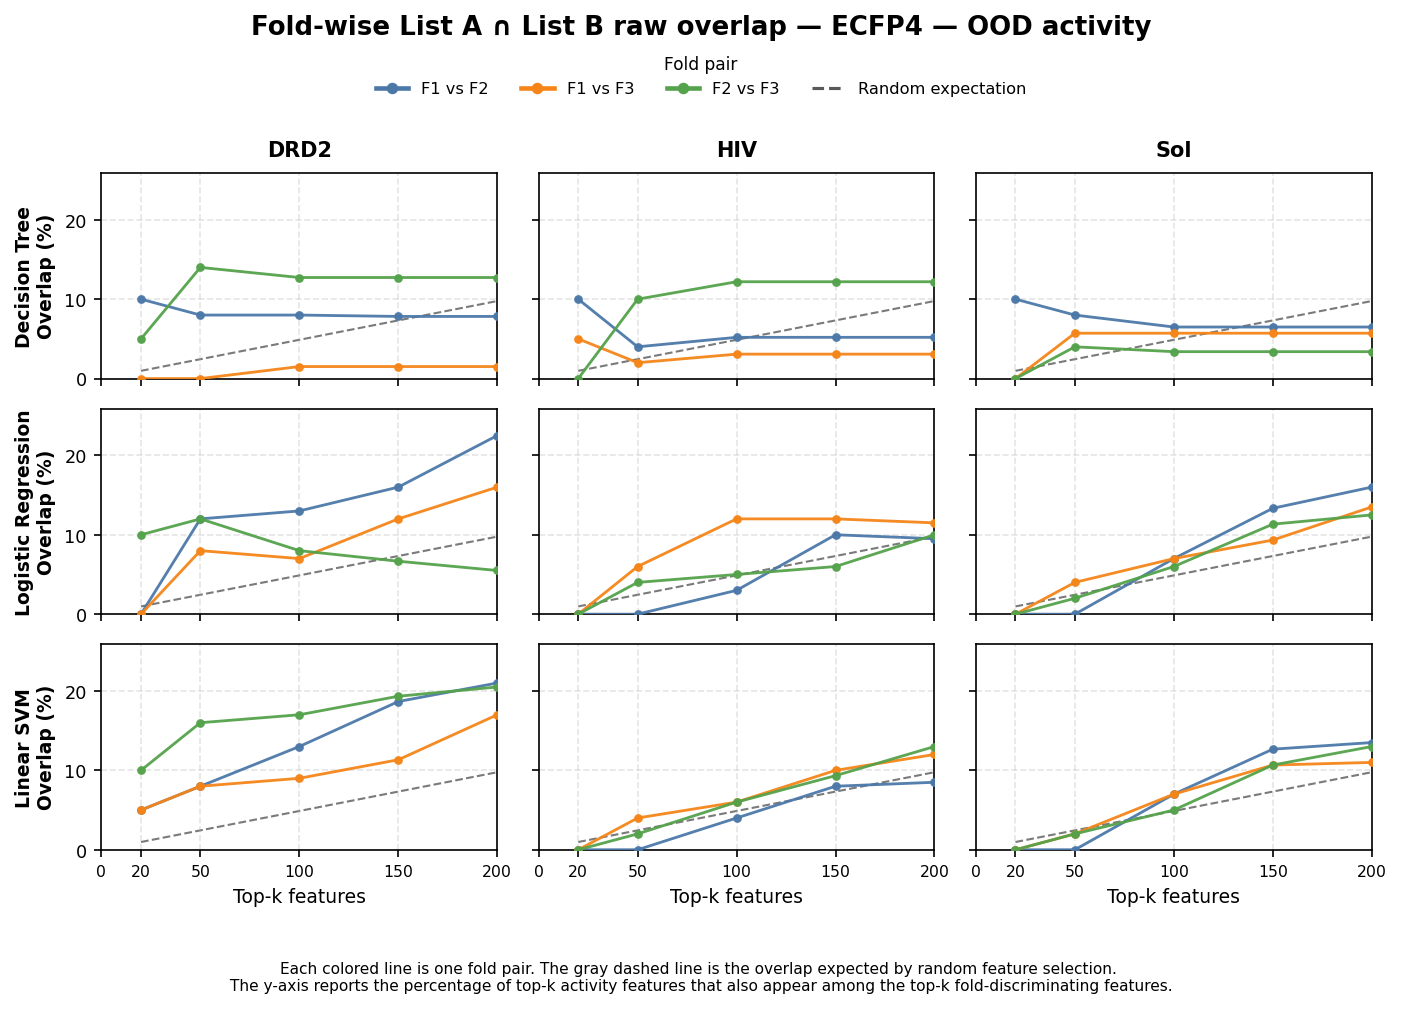

Saved: listA_listB_raw_overlap_foldwise_ood_linear_maccs.png
Saved: listA_listB_raw_overlap_foldwise_ood_linear_maccs.pdf


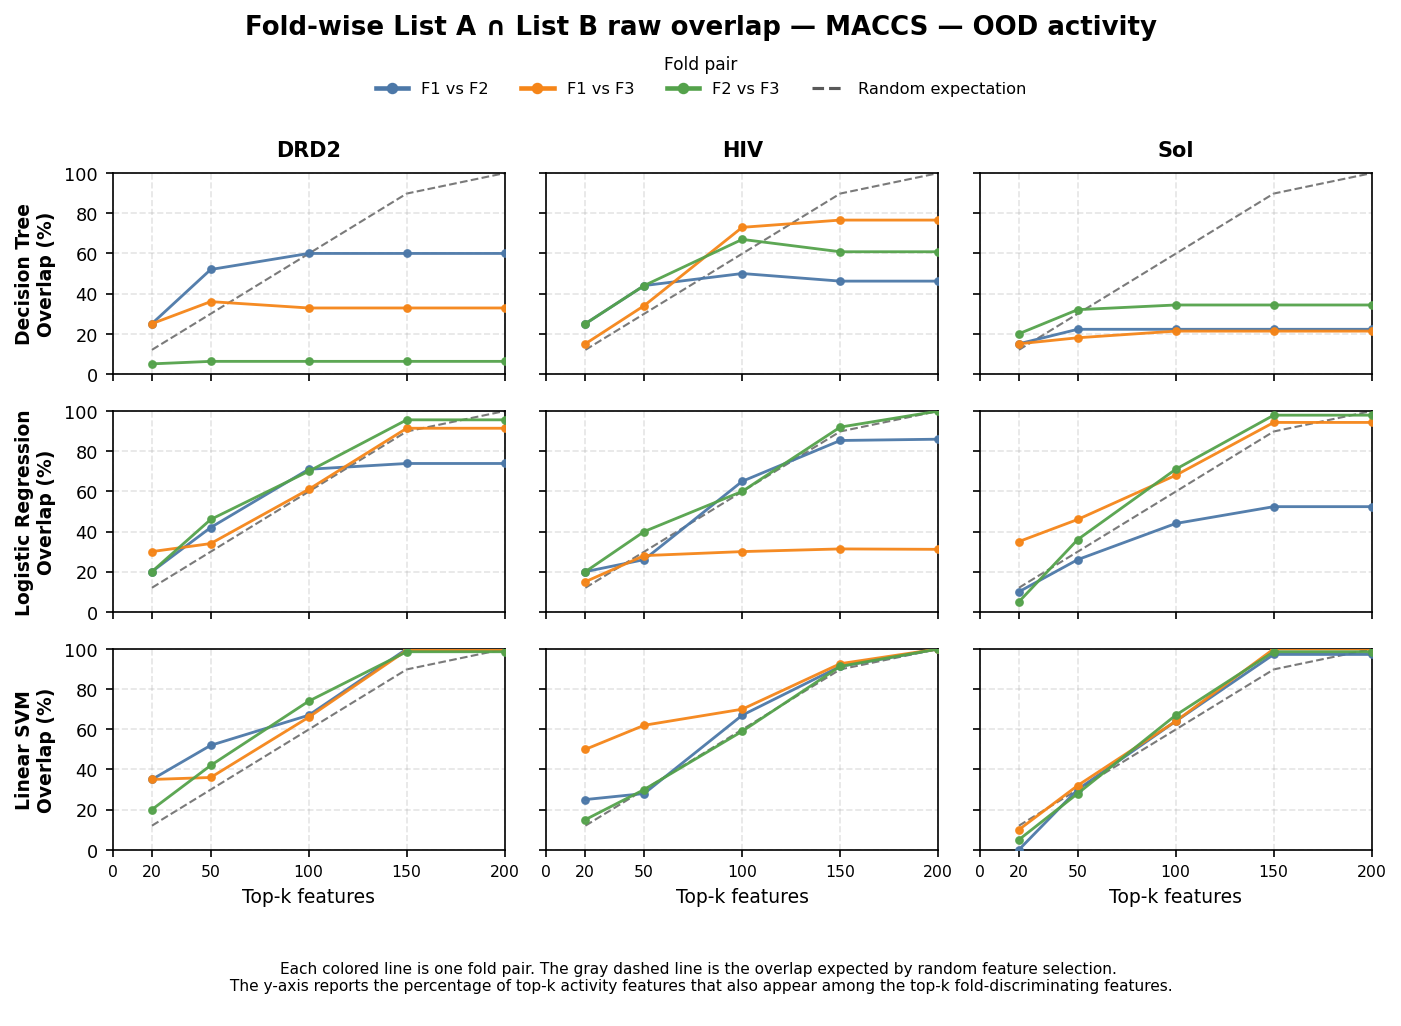

Saved: listA_listB_raw_overlap_foldwise_random_linear_ecfp4.png
Saved: listA_listB_raw_overlap_foldwise_random_linear_ecfp4.pdf


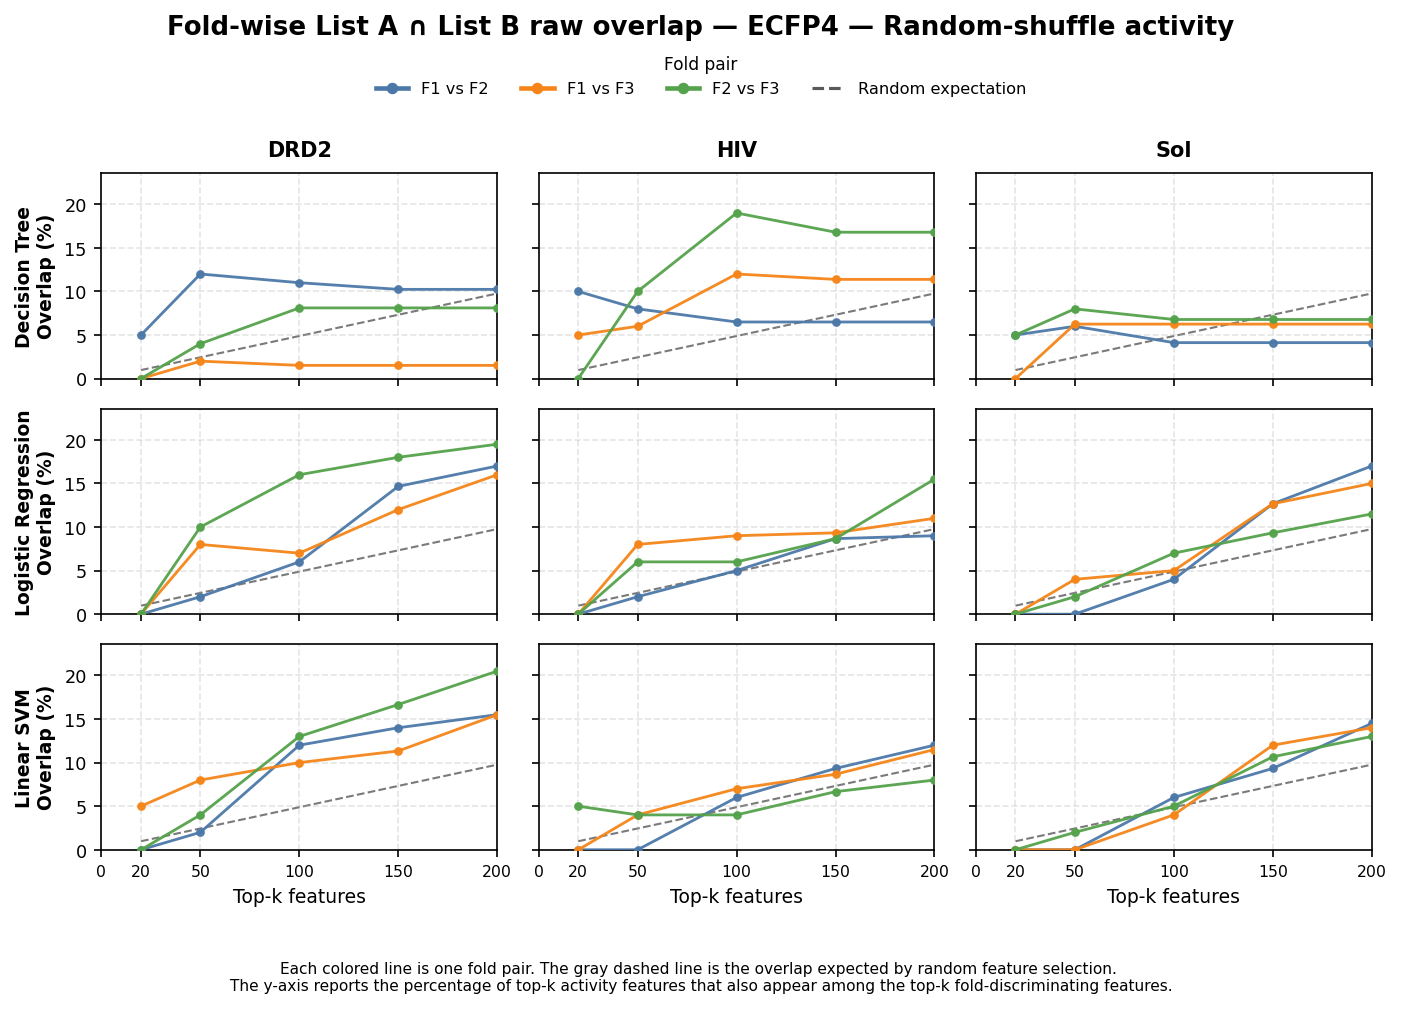

Saved: listA_listB_raw_overlap_foldwise_random_linear_maccs.png
Saved: listA_listB_raw_overlap_foldwise_random_linear_maccs.pdf


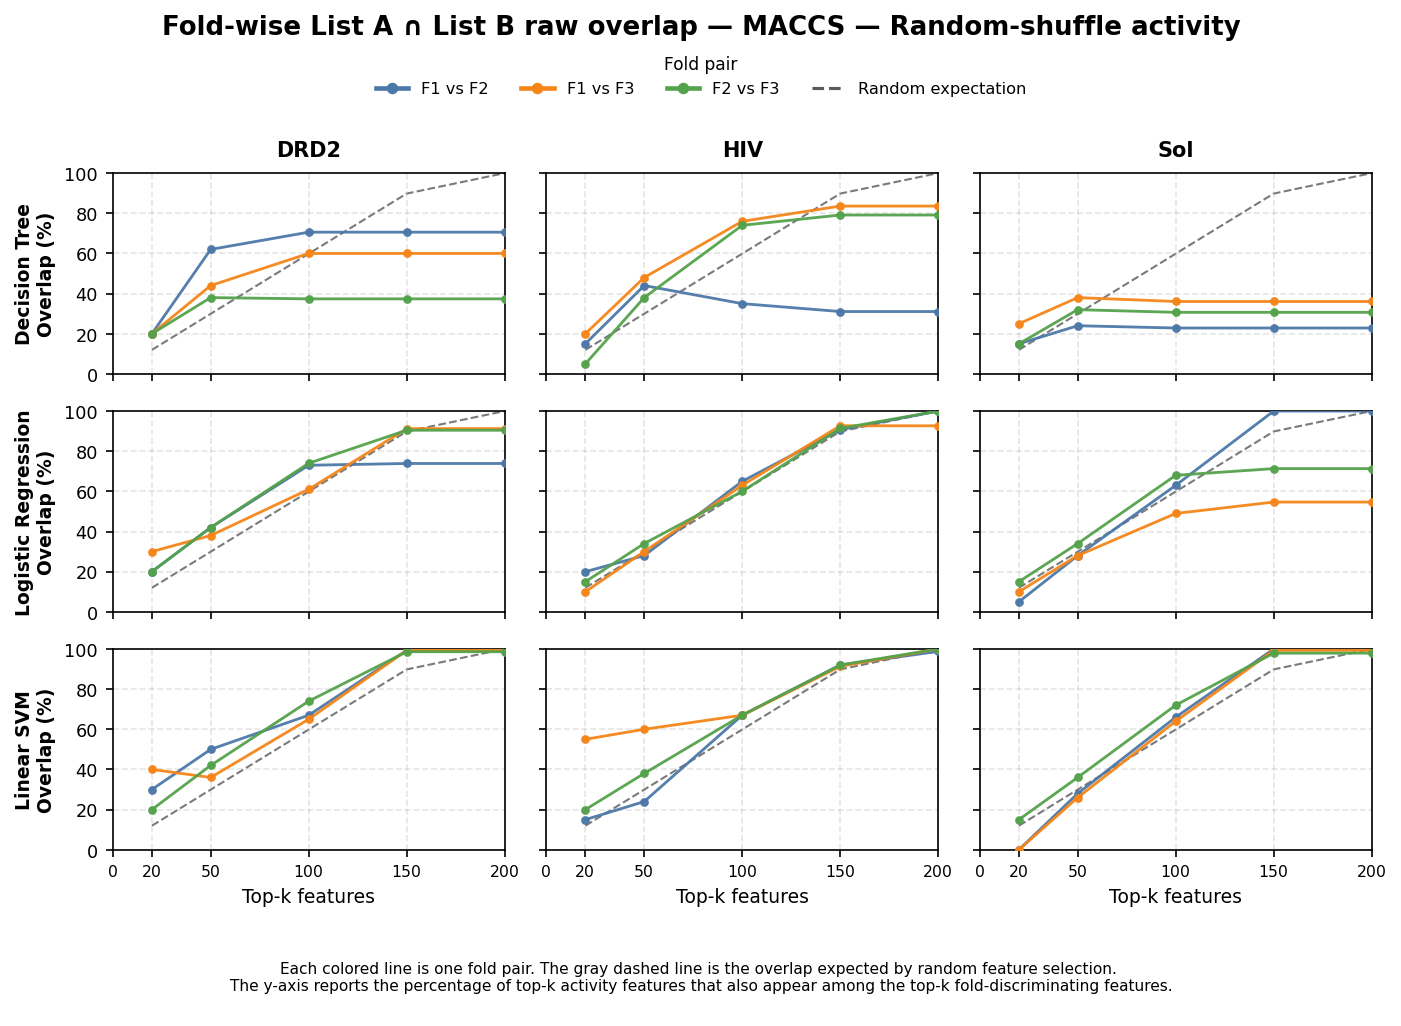

In [8]:
# Fold-wise List A vs List B raw overlap.
# Keeps fold pairs separated; OOD and random activity protocols are plotted in separate figures.


def plot_listA_listB_overlap_foldwise_compact_linear_x(
    df_overlap: pd.DataFrame,
    fingerprints=("ECFP4", "MACCS"),
    activity_protocol: str = "ood",
    k_values_plot=(20, 50, 100, 150, 200),
):
    from matplotlib.lines import Line2D

    required_cols = [
        "dataset",
        "pair",
        "fingerprint",
        "model",
        "k",
        "activity_protocol",
        "overlap",
    ]

    missing = [c for c in required_cols if c not in df_overlap.columns]
    if missing:
        raise ValueError(f"Missing required columns in df_overlap: {missing}")

    activity_protocol = str(activity_protocol).strip().lower()

    if activity_protocol not in {"ood", "random"}:
        raise ValueError("activity_protocol must be either 'ood' or 'random'.")

    fig_root = OUT_ROOT / "figures"
    fig_root.mkdir(parents=True, exist_ok=True)

    df = df_overlap.copy()

    df["k"] = pd.to_numeric(df["k"], errors="coerce")
    df["overlap"] = pd.to_numeric(df["overlap"], errors="coerce")

    df = df.dropna(subset=["k", "overlap"])
    df["k"] = df["k"].astype(int)

    available_k = sorted(df["k"].unique())
    missing_k = [k for k in k_values_plot if k not in available_k]

    if missing_k:
        print(
            "WARNING: these k values are requested for the plot but are not present "
            f"in df_overlap: {missing_k}"
        )
        print(f"Available k values in df_overlap: {available_k}")

    df = df[df["k"].isin(k_values_plot)].copy()

    if df.empty:
        raise ValueError(
            "No rows left after filtering df_overlap by k_values_plot. "
            f"Requested k_values_plot={k_values_plot}, available_k={available_k}"
        )

    df["activity_protocol"] = df["activity_protocol"].astype(str).str.lower()
    df = df[df["activity_protocol"] == activity_protocol].copy()

    if df.empty:
        raise ValueError(
            f"No rows available for activity_protocol={activity_protocol!r}."
        )

    df["fingerprint_norm"] = df["fingerprint"].astype(str).str.upper()

    if "model_short" not in df.columns:
        model_short_map = {
            "Decision Tree": "DT",
            "Logistic Regression": "LR",
            "Linear SVM": "SVM",
            "DT": "DT",
            "LR": "LR",
            "SVM": "SVM",
        }

        df["model_short"] = (
            df["model"].map(model_short_map).fillna(df["model"].astype(str))
        )

    model_order = ["DT", "LR", "SVM"]

    model_labels = {
        "DT": "Decision Tree",
        "LR": "Logistic Regression",
        "SVM": "Linear SVM",
    }

    protocol_labels = {
        "ood": "OOD activity",
        "random": "Random-shuffle activity",
    }

    protocol_label = protocol_labels[activity_protocol]

    pair_order = ["F1_vs_F2", "F1_vs_F3", "F2_vs_F3"]

    pair_labels = {
        "F1_vs_F2": "F1 vs F2",
        "F1_vs_F3": "F1 vs F3",
        "F2_vs_F3": "F2 vs F3",
    }

    pair_colors = {
        "F1_vs_F2": "#4C78A8",
        "F1_vs_F3": "#F58518",
        "F2_vs_F3": "#54A24B",
    }

    dataset_labels = {
        "drd2": "DRD2",
        "hiv": "HIV",
        "sol": "Sol",
    }

    if "DATASETS_MAIN" in globals():
        dataset_order = [d for d in DATASETS_MAIN if d in df["dataset"].unique()]
    else:
        dataset_order = [
            d for d in ["drd2", "hiv", "sol"] if d in df["dataset"].unique()
        ]

    if len(dataset_order) == 0:
        raise ValueError("No expected datasets found in df_overlap.")

    fp_n_features = {
        "ECFP4": 2048,
        "MACCS": 167,
    }

    out = {}

    for fp in fingerprints:
        fp_norm = str(fp).upper()
        fp_df = df[df["fingerprint_norm"] == fp_norm].copy()

        if fp_df.empty:
            print(f"No rows available for fingerprint={fp}. Skipping.")
            continue

        group_cols = [
            "dataset",
            "model_short",
            "pair",
            "fingerprint_norm",
            "k",
        ]

        # Aggregate only exact duplicates. This does not average across fold pairs,
        # models, datasets, or activity protocols.
        plot_df = fp_df.groupby(group_cols, as_index=False).agg(
            overlap=("overlap", "mean"),
        )

        plot_df["overlap_percent"] = 100.0 * plot_df["overlap"]

        n_features = fp_n_features.get(fp_norm)

        if n_features is None:
            raise ValueError(f"Unknown fingerprint size for {fp_norm}")

        expectation_df = pd.DataFrame(
            {
                "k": list(k_values_plot),
            }
        )

        expectation_df["effective_k"] = expectation_df["k"].clip(upper=n_features)
        expectation_df["random_expected_percent"] = (
            100.0 * expectation_df["effective_k"] / n_features
        )

        finite_values = (
            plot_df["overlap_percent"].replace([np.inf, -np.inf], np.nan).dropna()
        )

        if len(finite_values) == 0:
            print(f"No finite overlap values for fingerprint={fp}. Skipping.")
            continue

        y_max_data = float(np.nanmax(finite_values))
        y_max_random = float(expectation_df["random_expected_percent"].max())

        y_upper = min(
            100.0,
            max(10.0, 1.15 * max(y_max_data, y_max_random)),
        )

        fig, axes = plt.subplots(
            len(model_order),
            len(dataset_order),
            figsize=(9.4, 5.9),
            sharex=True,
            sharey=True,
            squeeze=False,
        )

        for i, model_short in enumerate(model_order):
            for j, dataset in enumerate(dataset_order):
                ax = axes[i, j]

                # Random expectation baseline.
                ax.plot(
                    expectation_df["k"],
                    expectation_df["random_expected_percent"],
                    color="0.35",
                    linestyle="--",
                    linewidth=1.0,
                    alpha=0.80,
                    zorder=1,
                )

                panel_df = plot_df[
                    (plot_df["dataset"] == dataset)
                    & (plot_df["model_short"] == model_short)
                ].copy()

                for pair in pair_order:
                    sub = panel_df[panel_df["pair"] == pair].sort_values("k").copy()

                    if sub.empty:
                        continue

                    ax.plot(
                        sub["k"],
                        sub["overlap_percent"],
                        marker="o",
                        markersize=3.2,
                        lw=1.35,
                        color=pair_colors.get(pair, "C0"),
                        alpha=0.95,
                        zorder=3,
                    )

                ax.set_xlim(0, 200)
                ax.set_xticks([0, 20, 50, 100, 150, 200])
                ax.set_xticklabels(
                    ["0", "20", "50", "100", "150", "200"],
                    rotation=0,
                )

                ax.set_ylim(0, y_upper)
                ax.grid(ls="--", alpha=0.32)

                if i == 0:
                    ax.set_title(
                        dataset_labels.get(dataset, dataset.upper()),
                        fontweight="bold",
                        pad=8,
                    )

                if j == 0:
                    ax.set_ylabel(
                        f"{model_labels.get(model_short, model_short)}\n" "Overlap (%)",
                        fontweight="bold",
                    )

                if i == len(model_order) - 1:
                    ax.set_xlabel("Top-k features")

        pair_handles = [
            Line2D(
                [0],
                [0],
                color=pair_colors[pair],
                lw=2.2,
                marker="o",
                markersize=4.5,
                label=pair_labels[pair],
            )
            for pair in pair_order
        ]

        random_handle = Line2D(
            [0],
            [0],
            color="0.35",
            lw=1.5,
            linestyle="--",
            label="Random expectation",
        )

        fig.legend(
            handles=pair_handles + [random_handle],
            loc="upper center",
            ncol=4,
            frameon=False,
            bbox_to_anchor=(0.5, 1.015),
            title="Fold pair",
            fontsize=7.8,
            title_fontsize=8.2,
        )

        fig.suptitle(
            f"Fold-wise List A ∩ List B raw overlap — {fp_norm} — {protocol_label}",
            fontweight="bold",
            fontsize=12.5,
            y=1.045,
        )

        fig.text(
            0.5,
            -0.025,
            "Each colored line is one fold pair. The gray dashed line is the overlap expected by random feature selection. \n "
            "The y-axis reports the percentage of top-k activity features that also appear among the top-k fold-discriminating features. \n",
            ha="center",
            va="top",
            fontsize=7.4,
        )

        fig.tight_layout(rect=[0, 0.015, 1, 0.975])

        fp_name = fp_norm.lower()

        fname_png = (
            fig_root
            / f"listA_listB_raw_overlap_foldwise_{activity_protocol}_linear_{fp_name}.png"
        )
        fname_pdf = (
            fig_root
            / f"listA_listB_raw_overlap_foldwise_{activity_protocol}_linear_{fp_name}.pdf"
        )

        fig.savefig(fname_png, dpi=600, bbox_inches="tight")
        fig.savefig(fname_pdf, bbox_inches="tight")

        print(f"Saved: {fname_png.name}")
        print(f"Saved: {fname_pdf.name}")

        plt.show()
        plt.close(fig)

        out[fp_norm] = plot_df

    return out


listA_listB_raw_overlap_foldwise_ood = (
    plot_listA_listB_overlap_foldwise_compact_linear_x(
        df_overlap,
        fingerprints=("ECFP4", "MACCS"),
        activity_protocol="ood",
        k_values_plot=(20, 50, 100, 150, 200),
    )
)

listA_listB_raw_overlap_foldwise_random = (
    plot_listA_listB_overlap_foldwise_compact_linear_x(
        df_overlap,
        fingerprints=("ECFP4", "MACCS"),
        activity_protocol="random",
        k_values_plot=(20, 50, 100, 150, 200),
    )
)

## Global Feature-Overlap Heatmap

### In general, to what extent do activity features coincide with shift features, regardless of whether the activity model is derived from OOD or generated randomly?


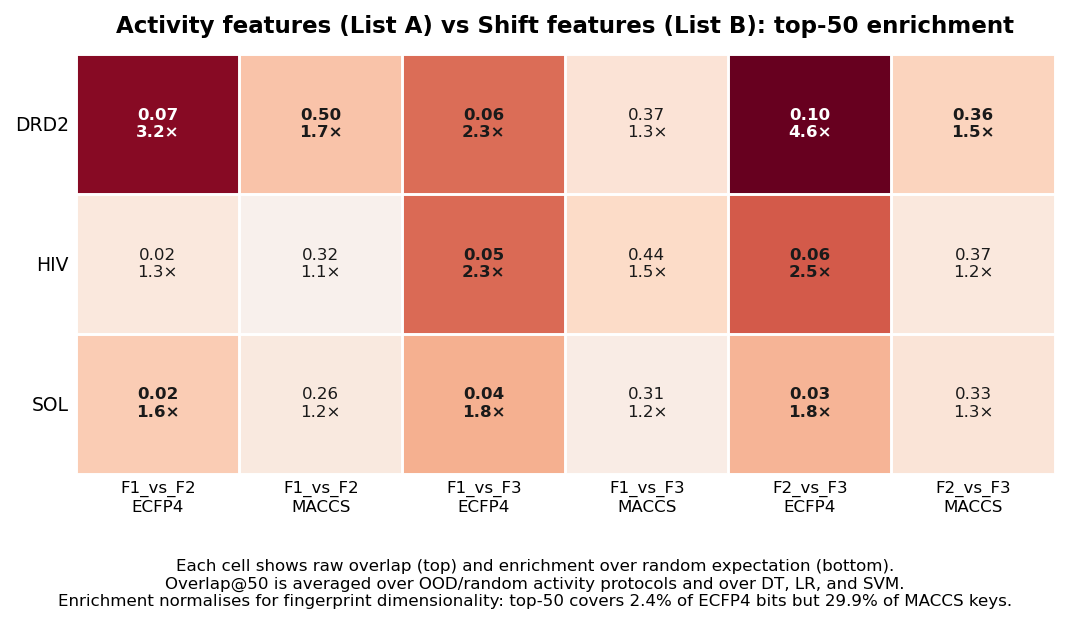

In [9]:
df_overlap_plot_k = df_overlap[df_overlap["k"].astype(int) == int(OVERLAP_K)].copy()

df_overlap_plot = df_overlap_plot_k.groupby(
    ["dataset", "pair", "fingerprint"], as_index=False
).agg(
    overlap=("overlap", "mean"),
    overlap_enrichment=("overlap_enrichment", "mean"),
)

df_overlap_plot["column"] = (
    df_overlap_plot["pair"] + "\n" + df_overlap_plot["fingerprint"].str.upper()
)

enrichment_mat = df_overlap_plot.pivot(
    index="dataset", columns="column", values="overlap_enrichment"
).reindex(DATASETS)

overlap_mat = df_overlap_plot.pivot(
    index="dataset", columns="column", values="overlap"
).reindex(DATASETS)

ordered_cols = []
for pair in ["F1_vs_F2", "F1_vs_F3", "F2_vs_F3"]:
    for fp in ["ECFP4", "MACCS"]:
        col = f"{pair}\n{fp}"
        if col in overlap_mat.columns:
            ordered_cols.append(col)

enrichment_mat = enrichment_mat[ordered_cols]
overlap_mat = overlap_mat[ordered_cols]

mpl.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 9,
        "axes.titlesize": 11,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 9,
        "figure.dpi": 150,
        "savefig.dpi": 600,
        "axes.linewidth": 0.8,
    }
)

n_rows, n_cols = enrichment_mat.shape

fig, ax = plt.subplots(figsize=(7.2, 3.6))

data = np.ma.masked_invalid(enrichment_mat.values.astype(float))

finite_enr = (
    df_overlap_plot["overlap_enrichment"].replace([np.inf, -np.inf], np.nan).dropna()
)

vcenter = 1.0
vmin = 0.0
vmax = float(max(2.0, np.nanpercentile(finite_enr, 95)))

norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

cmap = mpl.colormaps["RdBu_r"].copy()
cmap.set_bad(color="lightgray")

im = ax.imshow(
    data,
    cmap=cmap,
    norm=norm,
    aspect="auto",
    interpolation="nearest",
)

ax.set_title(
    f"Activity features (List A) vs Shift features (List B): top-{OVERLAP_K} enrichment",
    pad=10,
    fontweight="bold",
)

ax.set_xticks(np.arange(n_cols))
ax.set_xticklabels(overlap_mat.columns, rotation=0, ha="center")

ax.set_yticks(np.arange(n_rows))
ax.set_yticklabels([d.upper() for d in overlap_mat.index])

ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)

ax.grid(which="minor", color="white", linewidth=1.4)
ax.tick_params(which="minor", bottom=False, left=False)
ax.tick_params(axis="both", length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

text_threshold = vcenter + 0.65 * (vmax - vcenter)

for i in range(n_rows):
    for j in range(n_cols):
        raw = overlap_mat.iloc[i, j]
        enr = enrichment_mat.iloc[i, j]

        if pd.notna(raw) and pd.notna(enr):
            color = "white" if enr >= text_threshold else "0.10"
            weight = "bold" if enr >= 1.5 else "normal"

            ax.text(
                j,
                i,
                f"{raw:.2f}\n{enr:.1f}×",
                ha="center",
                va="center",
                fontsize=8,
                color=color,
                fontweight=weight,
            )

cbar.set_label(
    "Enrichment over random expectation\n(1.0 = chance)",
    rotation=270,
    labelpad=22,
)

cbar.set_label(
    f"Feature overlap@{OVERLAP_K}",
    rotation=270,
    labelpad=13,
)

cbar.ax.tick_params(length=0)

fig.text(
    0.5,
    -0.045,
    "Each cell shows raw overlap (top) and enrichment over random expectation (bottom).\n"
    f"Overlap@{OVERLAP_K} is averaged over OOD/random activity protocols and over DT, LR, and SVM.\n"
    f"Enrichment normalises for fingerprint dimensionality: top-{OVERLAP_K} covers "
    f"{OVERLAP_K / 2048:.1%} of ECFP4 bits but {OVERLAP_K / 167:.1%} of MACCS keys.",
    ha="center",
    va="top",
    fontsize=8,
)

fig.tight_layout()

fig.savefig(
    FIG_ROOT / f"global_listA_listB_overlap_heatmap_top{OVERLAP_K}_paper_light.png",
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    FIG_ROOT / f"global_listA_listB_overlap_heatmap_top{OVERLAP_K}_paper_light.pdf",
    bbox_inches="tight",
)

plt.show()

## Scatter Plot: Shift Score vs OOD Test Benefit

Are the chemically most distinguishable folds also the ones where OOD validation is most helpful?


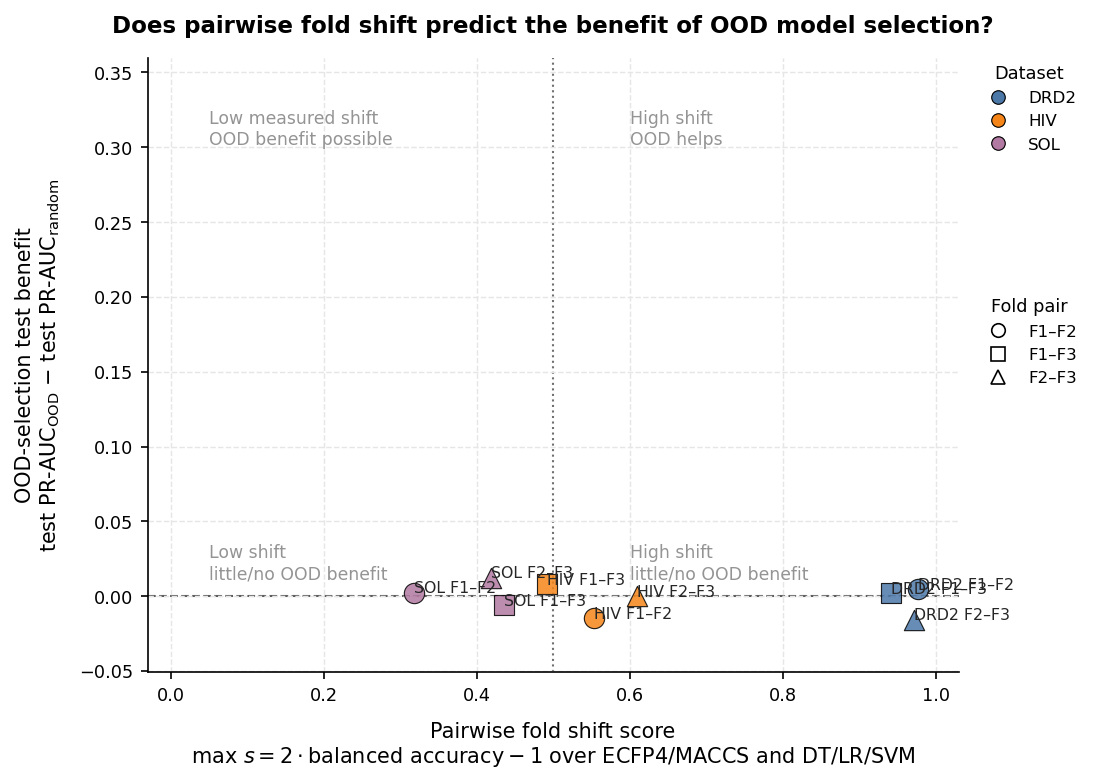

In [10]:
# Plot: pairwise fold shift vs OOD-selection test benefit

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

# from adjustText import adjust_text

FIG_ROOT = OUT_ROOT / "figures"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

df_shift_gap = df_shift_gap[df_shift_gap["dataset"].isin(DATASETS_MAIN)].copy()

mpl.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "legend.fontsize": 8,
        "legend.title_fontsize": 8.5,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.dpi": 600,
        "axes.linewidth": 0.8,
    }
)

# Positive value = OOD-based model selection improves final OOD test PR-AUC.
GAP_COL = "test_gap"

GAP_LABEL = (
    "OOD-selection test benefit\n"
    r"test PR-AUC$_{\mathrm{OOD}}$ $-$ test PR-AUC$_{\mathrm{random}}$"
)

SHIFT_THRESHOLD = 0.50

markers = {
    "F1_vs_F2": "o",
    "F1_vs_F3": "s",
    "F2_vs_F3": "^",
}

dataset_colors = {
    "DRD2": "#4C78A8",
    "HIV": "#F58518",
    "SOL": "#B279A2",
}

fig, ax = plt.subplots(figsize=(7.4, 5.3))

texts = []

for _, row in df_shift_gap.iterrows():
    dataset = row["dataset"].upper()
    pair = row["pair"]

    x = row["shift_score_01"]
    y = row[GAP_COL]

    ax.scatter(
        x,
        y,
        s=95,
        marker=markers.get(pair, "o"),
        facecolor=dataset_colors.get(dataset, "gray"),
        edgecolor="black",
        linewidth=0.55,
        alpha=0.85,
        zorder=3,
    )

    texts.append(
        ax.text(
            x,
            y,
            f"{dataset} {pair.replace('_vs_', '–')}",
            fontsize=7.6,
            color="0.15",
            zorder=4,
        )
    )


ax.axhline(
    0.0,
    color="0.25",
    linestyle="--",
    linewidth=1.0,
    alpha=0.85,
    zorder=1,
)

ax.axvline(
    SHIFT_THRESHOLD,
    color="0.25",
    linestyle=":",
    linewidth=1.0,
    alpha=0.75,
    zorder=1,
)

ax.set_xlim(-0.03, 1.03)

y_min = min(-0.04, df_shift_gap[GAP_COL].min() - 0.035)
y_max = max(0.36, df_shift_gap[GAP_COL].max() + 0.035)
ax.set_ylim(y_min, y_max)

ax.grid(
    True,
    linestyle="--",
    linewidth=0.7,
    color="0.90",
    zorder=0,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

quad_style = dict(
    fontsize=8.3,
    color="0.58",
    ha="left",
    va="top",
)

ax.text(
    0.05,
    y_max - 0.035,
    "Low measured shift\nOOD benefit possible",
    **quad_style,
)

ax.text(
    0.60,
    y_max - 0.035,
    "High shift\nOOD helps",
    **quad_style,
)

ax.text(
    0.60,
    0.035,
    "High shift\nlittle/no OOD benefit",
    fontsize=8.3,
    color="0.58",
    ha="left",
    va="top",
)

ax.text(
    0.05,
    0.035,
    "Low shift\nlittle/no OOD benefit",
    fontsize=8.3,
    color="0.58",
    ha="left",
    va="top",
)

ax.set_xlabel(
    "Pairwise fold shift score\n"
    r"max $s = 2 \cdot \mathrm{balanced\ accuracy} - 1$ over ECFP4/MACCS and DT/LR/SVM",
    labelpad=8,
)

ax.set_ylabel(GAP_LABEL, labelpad=8)

ax.set_title(
    "Does pairwise fold shift predict the benefit of OOD model selection?",
    pad=12,
    fontweight="bold",
)

dataset_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markerfacecolor=color,
        markeredgecolor="black",
        markeredgewidth=0.55,
        markersize=6.5,
        label=dataset,
    )
    for dataset, color in dataset_colors.items()
]

pair_handles = [
    Line2D(
        [0],
        [0],
        marker=marker,
        linestyle="",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=0.8,
        markersize=6.5,
        label=pair.replace("_vs_", "–"),
    )
    for pair, marker in markers.items()
]

legend_1 = ax.legend(
    handles=dataset_handles,
    title="Dataset",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    frameon=False,
    borderaxespad=0.0,
)

ax.add_artist(legend_1)

ax.legend(
    handles=pair_handles,
    title="Fold pair",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.62),
    frameon=False,
    borderaxespad=0.0,
)

fig.tight_layout()

fig.savefig(
    FIG_ROOT / "pairwise_shift_vs_test_gap_quadrants_paper.png",
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    FIG_ROOT / "pairwise_shift_vs_test_gap_quadrants_paper.pdf",
    bbox_inches="tight",
)

plt.show()

## Predictive-shift overlap vs OOD validation usefulness

Question:
Does OOD validation help more when the fold shift affects the same
features used by the activity model?


Descriptive pair-level correlations (n=9; dataset × fold-pair points):
  Pearson  = -0.525
  Spearman = -0.377
These are descriptive only; n is too small for statistical claims.


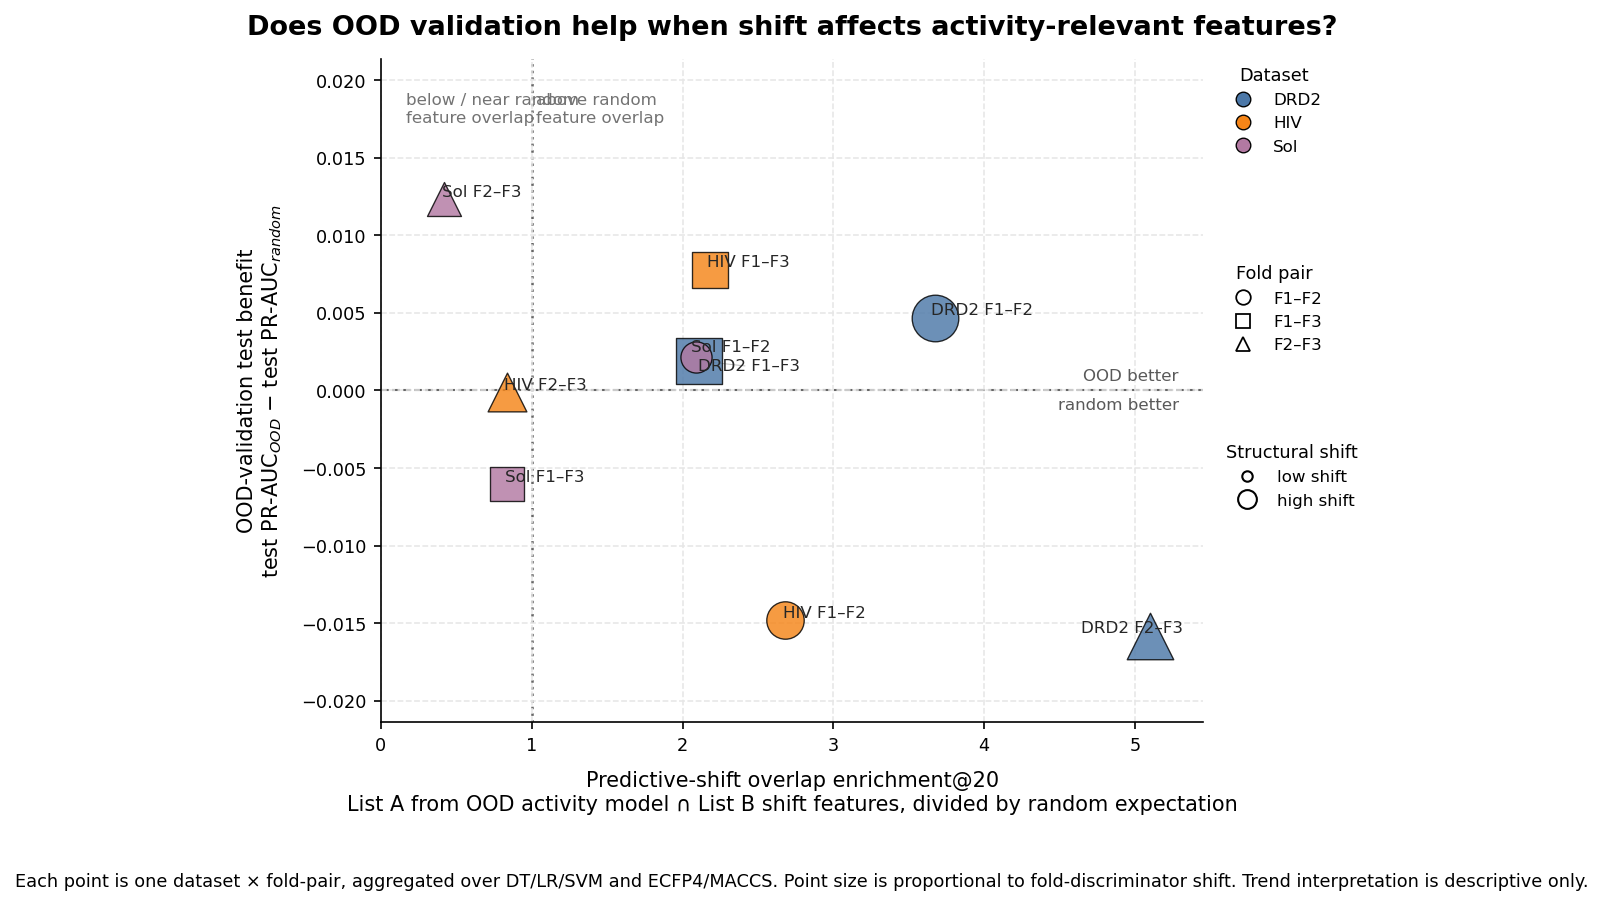

In [11]:
# 6. Descriptive correlations

corr_df = plot_df.dropna(
    subset=["overlap_ood_enrichment_mean", "test_benefit_mean"]
).copy()

if len(corr_df) >= 3:
    pearson_corr = corr_df["overlap_ood_enrichment_mean"].corr(
        corr_df["test_benefit_mean"],
        method="pearson",
    )
    spearman_corr = corr_df["overlap_ood_enrichment_mean"].corr(
        corr_df["test_benefit_mean"],
        method="spearman",
    )
else:
    pearson_corr = np.nan
    spearman_corr = np.nan

print(
    "Descriptive pair-level correlations "
    f"(n={len(corr_df)}; dataset × fold-pair points):\n"
    f"  Pearson  = {pearson_corr:.3f}\n"
    f"  Spearman = {spearman_corr:.3f}\n"
    "These are descriptive only; n is too small for statistical claims."
)


#  Plot

fig, ax = plt.subplots(figsize=(7.8, 5.6))

x_col = "overlap_ood_enrichment_mean"
y_col = "test_benefit_mean"

finite = plot_df.dropna(subset=[x_col, y_col]).copy()

if len(finite) == 0:
    raise ValueError("No finite rows available for plotting.")

x_min = min(0.0, finite[x_col].min() - 0.25)
x_max = finite[x_col].max() + 0.35

y_abs = max(
    abs(finite[y_col].min()),
    abs(finite[y_col].max()),
    0.01,
)

y_lim = 1.35 * y_abs

ax.axhline(
    0.0,
    color="0.25",
    linestyle="--",
    linewidth=1.0,
    alpha=0.8,
    zorder=1,
)

ax.axvline(
    1.0,
    color="0.25",
    linestyle=":",
    linewidth=1.2,
    alpha=0.8,
    zorder=1,
)

texts = []

for _, row in finite.iterrows():
    dataset = row["dataset"]
    pair = row["pair"]

    size = 90 + 420 * float(row["shift_score_max"])

    ax.scatter(
        row[x_col],
        row[y_col],
        s=size,
        marker=PAIR_MARKERS.get(pair, "o"),
        facecolor=DATASET_COLORS.get(dataset, "gray"),
        edgecolor="black",
        linewidth=0.65,
        alpha=0.82,
        zorder=3,
    )

    texts.append(
        ax.text(
            row[x_col],
            row[y_col],
            f"{row['dataset_label']} {row['pair_label']}",
            fontsize=8,
            color="0.15",
            zorder=4,
        )
    )

try:
    from adjustText import adjust_text

    adjust_text(
        texts,
        ax=ax,
        expand=(1.15, 1.25),
        force_text=(0.30, 0.35),
        force_static=(0.15, 0.20),
        arrowprops=dict(
            arrowstyle="-",
            color="0.55",
            lw=0.45,
            alpha=0.60,
        ),
    )
except ImportError:
    print(
        "adjustText not installed; labels may overlap. Install with: pip install adjustText"
    )

ax.set_xlim(x_min, x_max)
ax.set_ylim(-y_lim, y_lim)

ax.grid(
    True,
    linestyle="--",
    linewidth=0.75,
    color="0.90",
    zorder=0,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlabel(
    "Predictive-shift overlap enrichment@20\n"
    "List A from OOD activity model ∩ List B shift features, divided by random expectation",
    fontsize=10,
    labelpad=8,
)

ax.set_ylabel(
    "OOD-validation test benefit\n" r"test PR-AUC$_{OOD}$ $-$ test PR-AUC$_{random}$",
    fontsize=10,
    labelpad=8,
)

ax.set_title(
    "Does OOD validation help when shift affects activity-relevant features?",
    fontsize=13,
    fontweight="bold",
    pad=12,
)

ax.text(
    1.03,
    y_lim * 0.90,
    "above random\nfeature overlap",
    fontsize=8,
    color="0.45",
    ha="left",
    va="top",
)

ax.text(
    x_min + 0.03 * (x_max - x_min),
    y_lim * 0.90,
    "below / near random\nfeature overlap",
    fontsize=8,
    color="0.45",
    ha="left",
    va="top",
)

ax.text(
    x_max - 0.03 * (x_max - x_min),
    0.02 * y_lim,
    "OOD better",
    fontsize=8,
    color="0.35",
    ha="right",
    va="bottom",
)

ax.text(
    x_max - 0.03 * (x_max - x_min),
    -0.02 * y_lim,
    "random better",
    fontsize=8,
    color="0.35",
    ha="right",
    va="top",
)

dataset_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markerfacecolor=color,
        markeredgecolor="black",
        markeredgewidth=0.65,
        markersize=7,
        label=DATASET_LABELS.get(dataset, dataset),
    )
    for dataset, color in DATASET_COLORS.items()
]

pair_handles = [
    Line2D(
        [0],
        [0],
        marker=marker,
        linestyle="",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=0.85,
        markersize=7,
        label=PAIR_LABELS.get(pair, pair),
    )
    for pair, marker in PAIR_MARKERS.items()
]

size_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=5,
        label="low shift",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=9,
        label="high shift",
    ),
]

legend_1 = ax.legend(
    handles=dataset_handles,
    title="Dataset",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    frameon=False,
    borderaxespad=0.0,
)

ax.add_artist(legend_1)

legend_2 = ax.legend(
    handles=pair_handles,
    title="Fold pair",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.70),
    frameon=False,
    borderaxespad=0.0,
)

ax.add_artist(legend_2)

ax.legend(
    handles=size_handles,
    title="Structural shift",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.43),
    frameon=False,
    borderaxespad=0.0,
)

fig.text(
    0.5,
    -0.045,
    "Each point is one dataset × fold-pair, aggregated over DT/LR/SVM and ECFP4/MACCS. "
    "Point size is proportional to fold-discriminator shift. Trend interpretation is descriptive only.",
    ha="center",
    va="top",
    fontsize=8.5,
)

fig.tight_layout()

fig.savefig(
    FIG_ROOT / f"predictive_shift_overlap_vs_ood_test_benefit_top{OVERLAP_K}.png",
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    FIG_ROOT / f"predictive_shift_overlap_vs_ood_test_benefit_top{OVERLAP_K}.pdf",
    bbox_inches="tight",
)

plt.show()